# Building an image classification/regression application system using a deep learning technique
## Import necessary libraries

In [67]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


# Optional if using Google Colab and Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data preprocessing

In [68]:
RACE_MAP = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others"
}

def parse_utkface_filename(filename: str):
    """
    Parse UTKFace filename: [age]_[gender]_[race]_[date&time].jpg
    Returns (age:int, gender:int, race:int) or None if invalid.
    """
    base = os.path.basename(filename)
    parts = base.split("_")
    if len(parts) < 4:
        return None

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])

        if not (0 <= age <= 116):
            return None
        if gender not in (0, 1):
            return None
        if race not in (0, 1, 2, 3, 4):
            return None

        return age, gender, race
    except:
        return None


In [69]:
#DATA_DIR = "./UTKFace"  # Local machine
DATA_DIR = "/content/drive/MyDrive/COIT29225_Assignment/UTKFace/" #Google drive / Google Colab use

files, ages, genders, races = [], [], [], []

for fn in os.listdir(DATA_DIR):
    if fn.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(DATA_DIR, fn)
        labels = parse_utkface_filename(fn)
        if labels is None:
            continue
        age, gender, race = labels
        files.append(path)
        ages.append(age)
        genders.append(gender)
        races.append(race)

files = np.array(files)
ages = np.array(ages, dtype=np.int32)
genders = np.array(genders, dtype=np.int32)
races = np.array(races, dtype=np.int32)

print("Total usable images:", len(files))
print("Age range:", ages.min(), "to", ages.max())
print("Gender counts", np.bincount(genders))
for i, count in enumerate(np.bincount(genders)):
    print(f"{'   Male' if i == 0 else '   Female'}: {count}")

print("Race counts:")
for i, count in enumerate(np.bincount(races)):
    print(f"   {RACE_MAP.get(i, 'Unknown')}: {count}")


Total usable images: 23708
Age range: 1 to 116
Gender counts [12391 11317]
   Male: 12391
   Female: 11317
Race counts:
   White: 10078
   Black: 4527
   Asian: 3435
   Indian: 3976
   Others: 1692


In [70]:
#Set parameter here for testing purpose

IMG_SIZE_DEF = 64
BATCH_SIZE = 32
EPOCHS_USED = 10
LEARNING_RATE = 0.001
AUGMENT_SETTING = True
MODEL_TYPE = "SimpleCNN"
#MODEL_TYPE = "VGG16"


In [71]:
def age_to_class(age):
    if age <= 24:
        return 0
    elif age <= 49:
        return 1
    elif age <= 74:
        return 2
    elif age <= 99:
        return 3
    else:
        return 4

age_classes = np.array([age_to_class(a) for a in ages])

train_files, test_files, train_age_class, test_age_class, \
train_gender, test_gender, train_age_real, test_age_real = train_test_split(
    files,
    age_classes,   # classified age
    genders,
    ages,          # real age
    test_size=0.2,
    random_state=42
)


IMG_SIZE = (IMG_SIZE_DEF, IMG_SIZE_DEF)

def load_image(path, age_label, gender_label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    return img, {
        "age": age_label,
        "gender": gender_label
    }

def make_dataset(files, ages, genders, training=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((files, ages, genders))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(2000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    if augment:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_files, train_age_class, train_gender, training=True, augment=AUGMENT_SETTING)
test_ds = make_dataset(test_files, test_age_class, test_gender, training=False, augment=AUGMENT_SETTING)


## Building the Model

In [72]:
def build_simple_cnn():
    inputs = layers.Input(shape=(IMG_SIZE_DEF, IMG_SIZE_DEF, 3))

    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Gender output
    gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)

    # Age output (5 classes)
    age_output = layers.Dense(5, activation="softmax", name="age")(x)

    model = models.Model(inputs=inputs, outputs=[age_output, gender_output])

    return model


def build_vgg16(img_size=(IMG_SIZE_DEF,IMG_SIZE_DEF), dense_units=256, dropout=0.4, train_backbone=False):
    base = tf.keras.applications.VGG16(include_top=False, weights="imagenet",
                                       input_shape=(img_size[0], img_size[1], 3))
    base.trainable = train_backbone

    inputs = layers.Input(shape=(img_size[0], img_size[1], 3))
    x = tf.keras.applications.vgg16.preprocess_input(inputs * 255.0)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    age_out = layers.Dense(5, activation="softmax", name="age")(x)
    gender_out = layers.Dense(1, activation="sigmoid", name="gender")(x)

    return models.Model(inputs, [age_out, gender_out], name="VGG16")

## Compile the Model

In [73]:
if MODEL_TYPE == "SimpleCNN":
  model = build_simple_cnn()
  modelplot_file_name = "SimpleCNNPlot_architecture.png"

if MODEL_TYPE == "VGG16":
  model = build_vgg16()
  modelplot_file_name = "VGG16Plot_Architecture.png"

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "age": "sparse_categorical_crossentropy",
        "gender": "binary_crossentropy"
    },
    metrics={
        "age": ["accuracy"],
        "gender": ["accuracy"]
    }
)

model.summary()

Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 64, 64, 3) │          0 │ input_layer_19[0… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_12         │ (None, 64, 64)    │          0 │ multiply_4[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_13         │ (None, 64, 64)    │          0 │ multiply_4[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_14         │ (None, 64, 64)    │          0 │ multiply_4[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 64, 64, 3) │          0 │ get_item_12[0][0… │
│                     │                   │            │ get_item_13[0][0… │
│                     │                   │            │ get_item_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 64, 3) │          0 │ stack_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 2, 2, 512) │ 14,714,688 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 5)         │      1,285 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

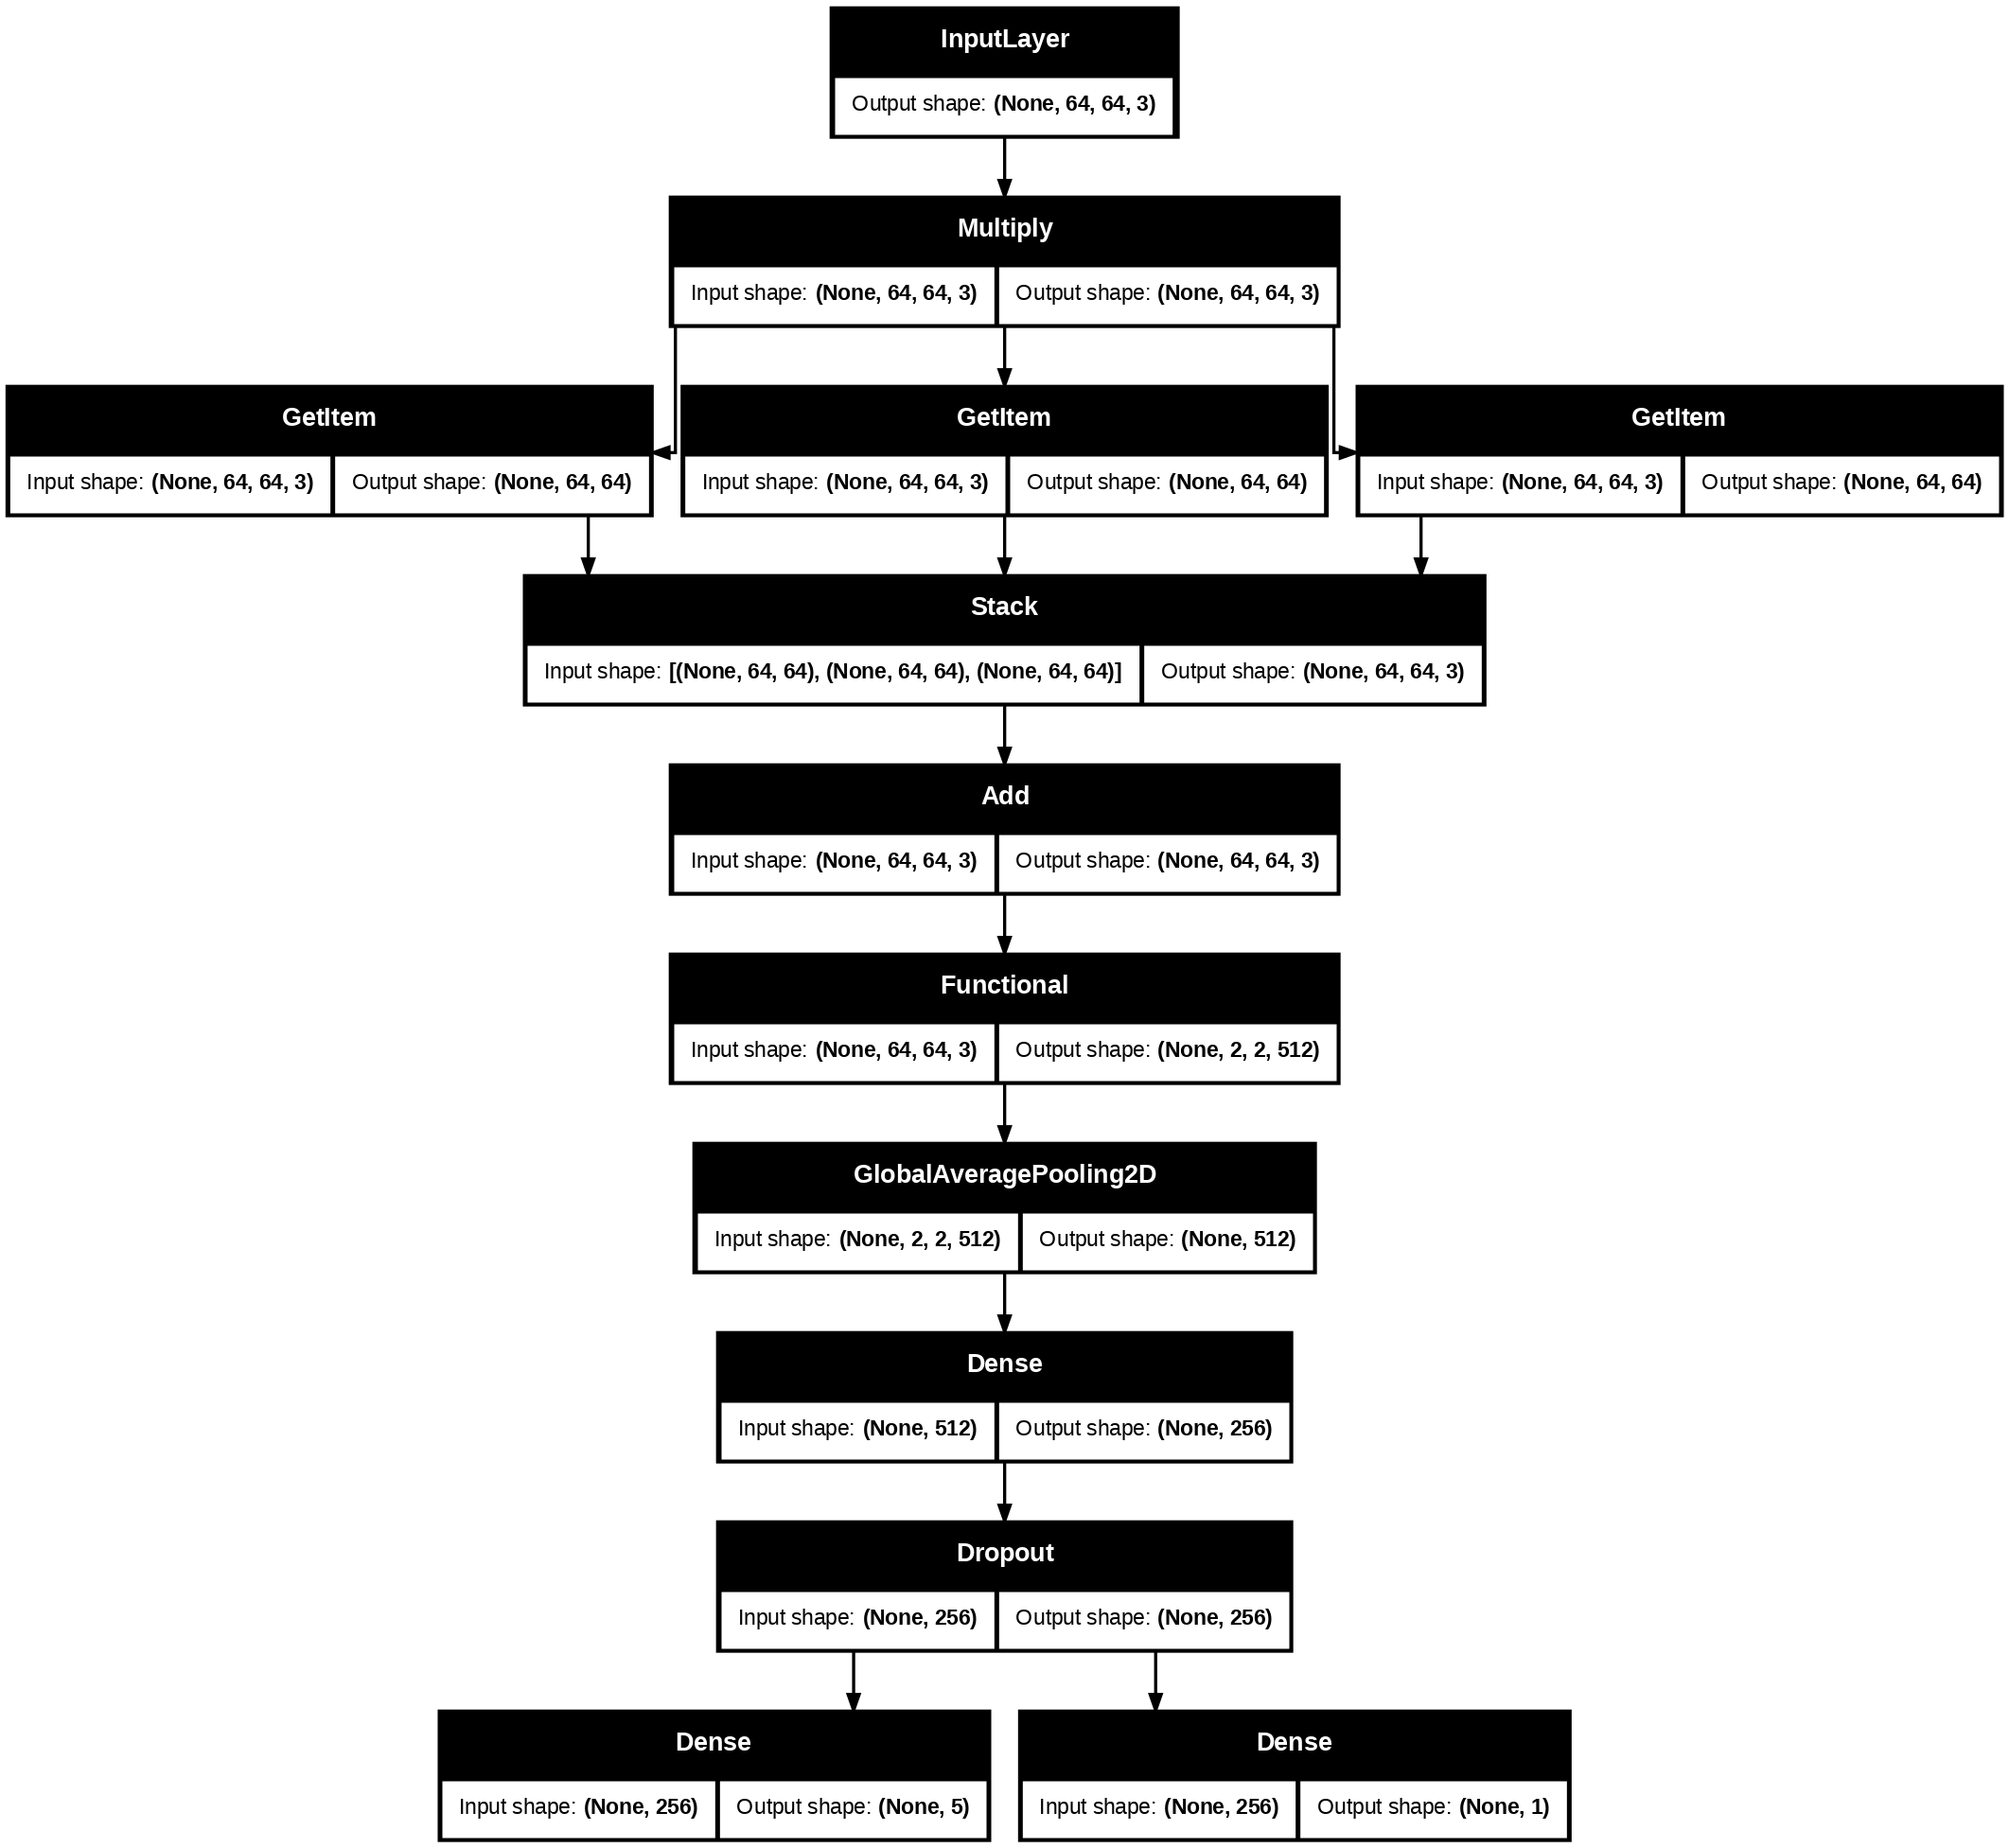

In [74]:
tf.keras.utils.plot_model(
    model,
    to_file=modelplot_file_name,
    show_shapes=True,
    dpi=120
)


In [75]:
# Add an early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_USED,
    callbacks=[early_stop]
)


Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 184s 298ms/step - age_accuracy: 0.4574 - age_loss: 6.5872 - gender_accuracy: 0.5959 - gender_loss: 2.8554 - loss: 9.4427 - val_age_accuracy: 0.6000 - val_age_loss: 1.5776 - val_gender_accuracy: 0.7672 - val_gender_loss: 0.7008 - val_loss: 2.2863
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - age_accuracy: 0.5416 - age_loss: 2.0209 - gender_accuracy: 0.7032 - gender_loss: 1.0055 - loss: 3.0263 - val_age_accuracy: 0.6031 - val_age_loss: 1.0680 - val_gender_accuracy: 0.7636 - val_gender_loss: 0.5459 - val_loss: 1.6162
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - age_accuracy: 0.5742 - age_loss: 1.2132 - gender_accuracy: 0.7317 - gender_loss: 0.6626 - loss: 1.8758 - val_age_accuracy: 0.6145 - val_age_loss: 0.9435 - val_gender_accuracy: 0.7771 - val_gender_loss: 0.5080 - val_loss: 1.4520
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - age_accuracy: 0.5910 - age_loss: 1.0260 - gender_accuracy: 0.7464 - gender_loss: 0.5698 - 

## Performance Visualization

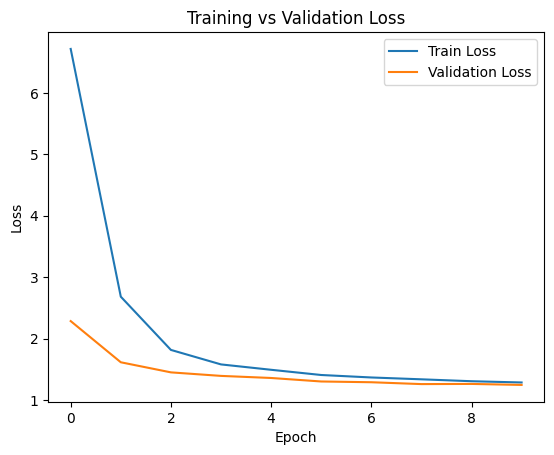

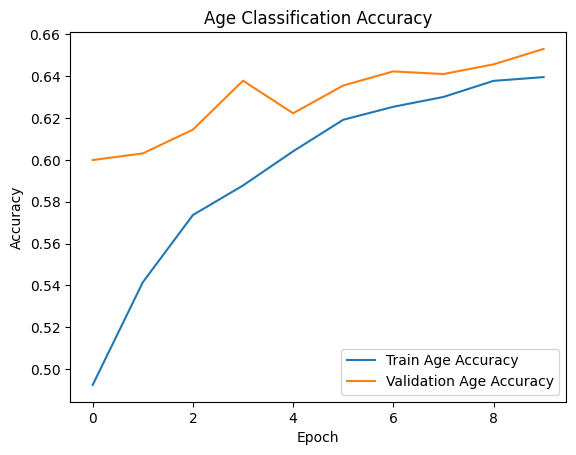

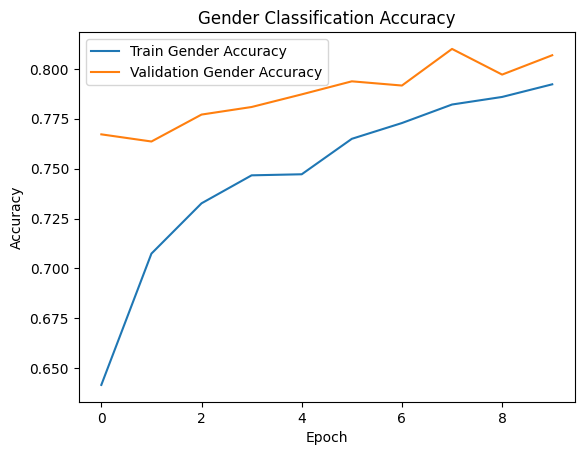

149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - age_accuracy: 0.6548 - age_loss: 0.8107 - gender_accuracy: 0.8019 - gender_loss: 0.4344 - loss: 1.2451

Test Performance:
age_accuracy: 0.6459
age_loss: 0.8131
gender_accuracy: 0.8020
gender_loss: 0.4308
loss: 1.2447


In [76]:
# LOSS
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# AGE ACCURACY
plt.figure()
plt.plot(history.history['age_accuracy'], label='Train Age Accuracy')
plt.plot(history.history['val_age_accuracy'], label='Validation Age Accuracy')
plt.title('Age Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# GENDER ACCURACY
plt.figure()
plt.plot(history.history['gender_accuracy'], label='Train Gender Accuracy')
plt.plot(history.history['val_gender_accuracy'], label='Validation Gender Accuracy')
plt.title('Gender Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

results = model.evaluate(test_ds, return_dict=True)

print("\nTest Performance:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


## Testing Sample Predictions (10 Samples)

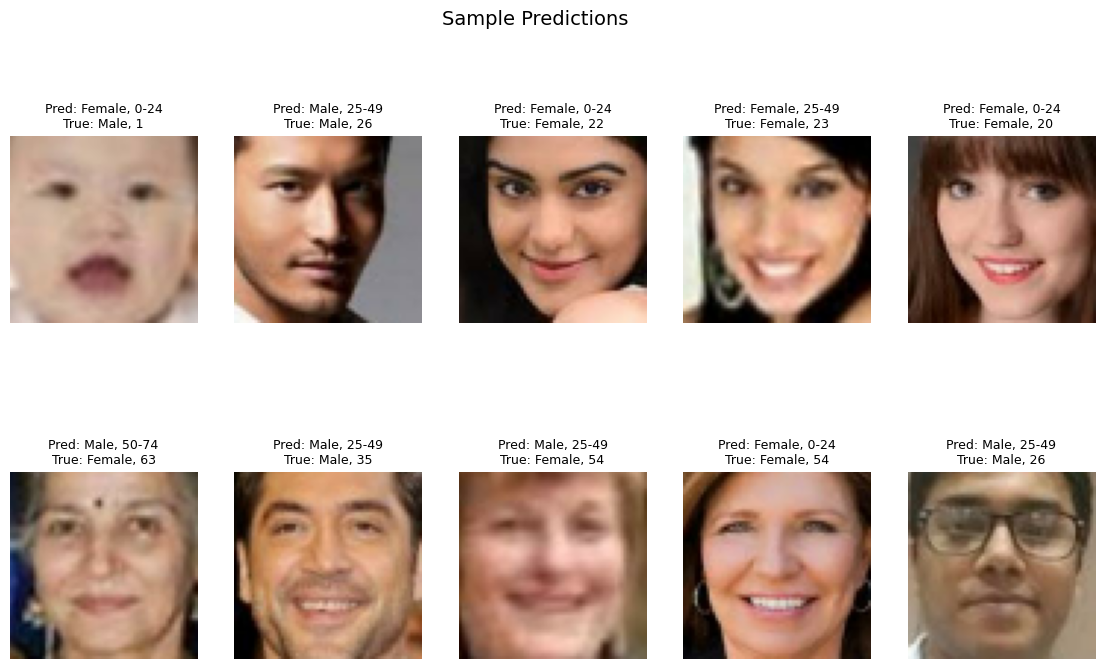

In [77]:
def gender_label(p):
    return "Female" if p > 0.5 else "Male"

def age_label(idx):
    age_groups = ["0-24", "25-49", "50-74", "75-99", "100+"]
    return age_groups[idx]

indices = np.random.choice(len(test_files), 10)

plt.figure(figsize=(14, 8))

for i, idx in enumerate(indices):
    path = test_files[idx]

    # TRUE LABELS
    true_age_real = test_age_real[idx]
    true_gender = test_gender[idx]

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img_resized = tf.image.resize(img, (IMG_SIZE_DEF,IMG_SIZE_DEF))
    img_norm = tf.cast(img_resized, tf.float32) / 255.0
    img_batch = tf.expand_dims(img_norm, 0)

    pred_age_class, pred_gender = model.predict(img_batch, verbose=0)

    age_pred = np.argmax(pred_age_class[0])
    gender_pred = pred_gender[0][0]

    plt.subplot(2,5,i+1)
    plt.imshow(tf.cast(img_resized, tf.uint8))
    plt.axis("off")
    plt.title(
        f"Pred: {gender_label(gender_pred)}, {age_label(age_pred)}\n"
        f"True: {gender_label(true_gender)}, {true_age_real}",
        fontsize=9
    )

plt.suptitle("Sample Predictions", fontsize=14)
plt.show()